Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021469116..536.5].


(1080, 1920, 3)


(10, 10, 10, 10)

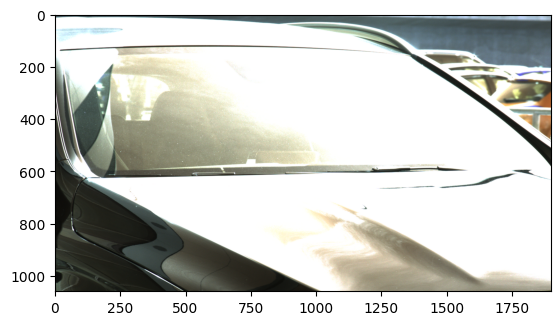

In [5]:
import cv2
import os
import numpy as np

#set environm export OPENCV_IO_ENABLE_OPENEXR=1
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"   # enable EXR IO in OpenCV

#first find margins on stuttgart dataset 
stuttgart_exr_path = "/data2/saikiran.tedla/hdrvideo/diff/data/stuttgart/cars_closeshot/cars_closeshot_000599.exr"

img = cv2.imread(stuttgart_exr_path, cv2.IMREAD_UNCHANGED)
print(img.shape)

cropped_img = img[10:-10,10:-10,:]#[:, :, ::-1]  #remove 10 pixel black border and convert BGR to RGB
import matplotlib.pyplot as plt
plt.imshow(img[10:-10,10:-10])

#write as png to check if borders are black
cv2.imwrite("/data2/saikiran.tedla/hdrvideo/diff/cropped.png", (np.clip(cropped_img, 0, 1) * 255).astype(np.uint8))


import numpy as np

def black_border_thickness(img, thresh=1e-6):
    """
    Returns (top, bottom, left, right) black border thickness in pixels.
    Assumes img is HxW or HxWxC (EXR float is fine).
    """

    if img.ndim == 3:
        black = np.all(img <= thresh, axis=2)   # HxW boolean mask
    else:
        black = img <= thresh

    H, W = black.shape

    # Count full-black rows from top
    top = 0
    while top < H and black[top, :].all():
        top += 1

    # Count full-black rows from bottom
    bottom = 0
    while bottom < H and black[H - 1 - bottom, :].all():
        bottom += 1

    # Count full-black cols from left
    left = 0
    while left < W and black[:, left].all():
        left += 1

    # Count full-black cols from right
    right = 0
    while right < W and black[:, W - 1 - right].all():
        right += 1

    return top, bottom, left, right


black_border_thickness(img)

In [6]:

#convert stuttgart to alexa srgb
alexa_to_srgb  = np.array([[ 1.617523, -0.537287, -0.080237],
                              [-0.070573,  1.334613, -0.26404 ],
                              [-0.021102, -0.226954,  1.248056]])
cv2_hdr_pred = cropped_img[:,:,::-1] @ alexa_to_srgb.T

cv2.imwrite("/data2/saikiran.tedla/hdrvideo/diff/cropped_srgb.png", (np.clip(cv2_hdr_pred[:,:,::-1], 0, 1) * 255).astype(np.uint8))




True

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-15.390625..150.75].


-15.390625 150.75
min_exposure: -7.236014191900085 max_exposure: 7.097624885513975


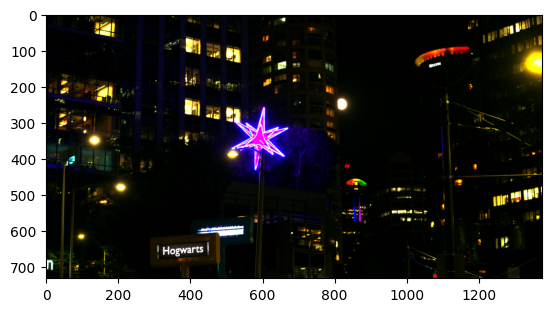

In [54]:
#load some of trevor's images in to see how that is
sample_path="/data2/saikiran.tedla/hdrvideo/diff/data/trevor/hdr_images_denoised/20240620_SHGCNCT_S001_S001_T133/f_001.exr"
sample_img = cv2.imread(sample_path, cv2.IMREAD_UNCHANGED)

print(np.min(sample_img), np.max(sample_img))

max_value = np.max(sample_img)
median_value = np.percentile(sample_img, 50)

min_exposure = np.log2(1/max_value)
max_exposure = np.log2(1/median_value)
print("min_exposure:", min_exposure, "max_exposure:", max_exposure)
plt.imshow(sample_img[:,:,::-1]*(2**-0))